# Importación de las librerías necesarias para la ejecución #

In [20]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

from scipy.stats import f_oneway
from scipy.stats import kendalltau, spearmanr
from scipy.stats import pointbiserialr

# Lectura de los datos de los partidos ya formateados en .csv

In [2]:
import os

dataframe_equipos = pd.read_csv("teams.csv")


dataframes_details = []
carpeta_details = "Details_Tochos/"  # Reemplaza "ruta/de/la/carpeta" con la ruta de la carpeta que deseas explorar

archivos = os.listdir(carpeta_details)
for archivo in archivos:
    df = pd.read_csv("Details_Tochos/"+archivo)
    df = df.iloc[::-1]
    dataframes_details.append(df)
details_partidos = pd.concat(dataframes_details, ignore_index=True)
print(details_partidos.shape)

dataframes = []
carpeta = "Datos_Formateados/"  # Reemplaza "ruta/de/la/carpeta" con la ruta de la carpeta que deseas explorar

archivos = os.listdir(carpeta)
for archivo in archivos:
    df = pd.read_csv("Datos_Formateados/"+archivo)
    df = df.iloc[::-1]
    dataframes.append(df)
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

with pd.ExcelWriter('Datos_Baloncesto_Completo.xlsx') as writer:
    archivos = os.listdir("Ejemplos/")
    i = 0
    for archivo in archivos:
        df = pd.read_csv("Ejemplos/"+archivo)
        df.to_excel(writer, sheet_name=f'Página {i+1}', index=False)
        i += 1

C:\Users\User\AppData\Local\Temp\ipykernel_4040\2197409058.py:11: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Details_Tochos/"+archivo)


(638857, 41)


In [3]:
datos_partidos = datos_partidos.dropna()
datos_partidos.shape

(25266, 22)

In [4]:
datos_partidos.head()

,Unnamed: 0,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,17903,2004-10-22,10400066,Final,1610612750,1610612752,2004,1610612750,102.0,0.523,...,32.0,46.0,1610612752,82.0,0.333,0.778,0.154,21.0,41.0,1
1,17902,2004-10-22,10400067,Final,1610612762,1610612758,2004,1610612762,103.0,0.507,...,25.0,43.0,1610612758,88.0,0.362,0.814,0.250,16.0,33.0,1
2,17901,2004-10-22,10400065,Final,1610612766,1610612757,2004,1610612766,69.0,0.377,...,24.0,36.0,1610612757,63.0,0.311,0.741,0.217,9.0,44.0,1
3,17900,2004-10-22,10400068,Final,1610612738,1610612751,2004,1610612738,83.0,0.431,...,14.0,34.0,1610612751,96.0,0.449,0.885,0.231,21.0,35.0,0
4,17899,2004-10-22,10400071,Final,1610612765,1610612764,2004,1610612765,100.0,0.549,...,24.0,34.0,1610612764,82.0,0.411,0.724,0.071,15.0,33.0,1


In [5]:
details_partidos.fillna(0, inplace=True)
details_partidos.head()

,Unnamed: 0.1,Unnamed: 0,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,...,FGM_Total,FG3M_Total,AST_Total,REB_Total,STL_Total,Mejor_FGM,Mejor_FG3M,Mejor_AST,Mejor_STL,Mejor_REB
0,32600,243640,40400407,1610612759,SAS,San Antonio,2757,Beno Udrih,0,0,...,205.0,69.0,174.0,104.0,50.0,0.0,0.0,0.0,0.0,0.0
1,32599,243639,40400407,1610612759,SAS,San Antonio,299,Glenn Robinson,0,0,...,51.0,5.0,9.0,47.0,7.0,0.0,0.0,0.0,0.0,0.0
2,32598,243638,40400407,1610612759,SAS,San Antonio,1725,Rasho Nesterovic,0,0,...,208.0,0.0,78.0,498.0,33.0,0.0,0.0,0.0,0.0,0.0
3,32597,243637,40400407,1610612759,SAS,San Antonio,763,Tony Massenburg,0,0,...,88.0,0.0,15.0,184.0,20.0,0.0,0.0,0.0,0.0,0.0
4,32596,243636,40400407,1610612759,SAS,San Antonio,2484,Devin Brown,0,0,...,188.0,48.0,103.0,204.0,42.0,0.0,0.0,0.0,0.0,0.0


In [6]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    equipos = dataframe["HOME_TEAM_ID"].drop_duplicates()
    return equipos

def get_nombres_equipo(lista_ids: list, dataframe_equipos: pd.DataFrame) -> list:
    list = []
    for equipo in lista_ids:
        list.append(dataframe_equipos.loc[dataframe_equipos['TEAM_ID'] == equipo, 'NICKNAME'].values[0])
    return list

equipos_ids = get_equipos(dataframe=datos_partidos)
equipos_nombres = get_nombres_equipo(lista_ids=equipos_ids, dataframe_equipos=dataframe_equipos)
len(equipos_nombres)

30

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [7]:
condicion = (datos_partidos['HOME_TEAM_WINS'] != 1) & (datos_partidos['HOME_TEAM_WINS'] != 0)
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

In [8]:
'''
def insertar_mejores_en_details(dataframe: pd.DataFrame, year:int):
    games_details = pd.read_csv("Details/"+str(year)+"-details.csv")
    dataframes_details = []
    mejores_anotadores_de_2 = ['','','','','']
    tiros_de_2_encestados_por_los_mejores = [0,0,0,0,0]
    mejores_anotadores_de_3 = ['','','','','']
    tiros_de_3_encestados_por_los_mejores = [0,0,0,0,0]
    mejores_asistidores = ['','','','','']
    asistencias_por_los_mejores = [0,0,0,0,0]
    mejores_stealers = ['','','','','']
    steals_por_los_mejores = [0,0,0,0,0]
    mejores_reboteadores = ['','','','','']
    rebotes_por_los_mejores = [0,0,0,0,0]
    for idx, partido in dataframe.iterrows():
        details_partido = games_details[games_details['GAME_ID'] == partido['GAME_ID']]
        for jugador in mejores_anotadores_de_2:
            details_partido.loc[details_partido['PLAYER_ID'] == jugador, 'Mejor_FGM'] = 1
        for jugador in mejores_anotadores_de_3:
            details_partido.loc[details_partido['PLAYER_ID'] == jugador, 'Mejor_FG3M'] = 1
        for jugador in mejores_asistidores:
            details_partido.loc[details_partido['PLAYER_ID'] == jugador, 'Mejor_AST'] = 1
        for jugador in mejores_stealers:
            details_partido.loc[details_partido['PLAYER_ID'] == jugador, 'Mejor_STL'] = 1
        for jugador in mejores_reboteadores:
            details_partido.loc[details_partido['PLAYER_ID'] == jugador, 'Mejor_REB'] = 1
            
        top_5_fgm = details_partido.sort_values(by='FGM_Total', ascending=False).head(5)
        fgm_top_5 = top_5_fgm['FGM_Total'].tolist()
        fgm_top_5_names = top_5_fgm['PLAYER_ID'].to_list()
        for i in range(len(tiros_de_2_encestados_por_los_mejores)):
            if fgm_top_5_names[i] not in mejores_anotadores_de_2:
                if fgm_top_5[i] > tiros_de_2_encestados_por_los_mejores[i]:
                    tiros_de_2_encestados_por_los_mejores.insert(i,fgm_top_5[i])
                    mejores_anotadores_de_2.insert(i,fgm_top_5_names[i])
                    mejores_anotadores_de_2.pop(-1)
                    tiros_de_2_encestados_por_los_mejores.pop(-1)
                    
        top_5_fg3m = details_partido.sort_values(by='FG3M_Total', ascending=False).head(5)
        fg3m_top_5 = top_5_fg3m['FGM_Total'].tolist()
        fg3m_top_5_names = top_5_fg3m['PLAYER_ID'].to_list()
        for i in range(len(tiros_de_3_encestados_por_los_mejores)):
            if fg3m_top_5_names[i] not in mejores_anotadores_de_3:
                if fg3m_top_5[i] > tiros_de_3_encestados_por_los_mejores[i]:
                    tiros_de_3_encestados_por_los_mejores.insert(i,fg3m_top_5[i])
                    mejores_anotadores_de_3.insert(i,fg3m_top_5_names[i])
                    mejores_anotadores_de_3.pop(-1)
                    tiros_de_3_encestados_por_los_mejores.pop(-1)
                    
        top_5_ast = details_partido.sort_values(by='AST_Total', ascending=False).head(5)
        ast_top_5 = top_5_ast['AST_Total'].tolist()
        ast_top_5_names = top_5_ast['PLAYER_ID'].to_list()
        for i in range(len(asistencias_por_los_mejores)):
            if ast_top_5_names[i] not in mejores_asistidores:
                if ast_top_5[i] > asistencias_por_los_mejores[i]:
                    asistencias_por_los_mejores.insert(i,ast_top_5[i])
                    mejores_asistidores.insert(i,ast_top_5_names[i])
                    mejores_asistidores.pop(-1)
                    asistencias_por_los_mejores.pop(-1)
                    
        top_5_reb = details_partido.sort_values(by='REB_Total', ascending=False).head(5)
        reb_top_5 = top_5_reb['REB_Total'].tolist()
        reb_top_5_names = top_5_reb['PLAYER_ID'].to_list()
        for i in range(len(rebotes_por_los_mejores)):
            if reb_top_5_names[i] not in mejores_reboteadores:
                if reb_top_5[i] > rebotes_por_los_mejores[i]:
                    rebotes_por_los_mejores.insert(i,reb_top_5[i])
                    mejores_reboteadores.insert(i,reb_top_5_names[i])
                    mejores_reboteadores.pop(-1)
                    rebotes_por_los_mejores.pop(-1)
                    
        top_5_stl = details_partido.sort_values(by='STL_Total', ascending=False).head(5)
        stl_top_5 = top_5_stl['STL_Total'].tolist()
        stl_top_5_names = top_5_stl['PLAYER_ID'].to_list()
        for i in range(len(steals_por_los_mejores)):
            if stl_top_5_names[i] not in mejores_stealers:
                if stl_top_5[i] > steals_por_los_mejores[i]:
                    steals_por_los_mejores.insert(i,stl_top_5[i])
                    mejores_stealers.insert(i,stl_top_5_names[i])
                    mejores_stealers.pop(-1)
                    steals_por_los_mejores.pop(-1)
                    
        dataframes_details.append(details_partido)
        
    dataframe_details_devuelto = pd.concat(dataframes_details, ignore_index=True)
    return dataframe_details_devuelto


year = 2018                
for idx,temporada in enumerate(dataframes):
    details_devuelto = insertar_mejores_en_details(dataframe=temporada, year=year)
    details_devuelto.to_csv("Details_Tochos/"+str(year)+"-details_tochos.csv")
    year += 1
'''

'\ndef insertar_mejores_en_details(dataframe: pd.DataFrame, year:int):\n    games_details = pd.read_csv("Details/"+str(year)+"-details.csv")\n    dataframes_details = []\n    mejores_anotadores_de_2 = [\'\',\'\',\'\',\'\',\'\']\n    tiros_de_2_encestados_por_los_mejores = [0,0,0,0,0]\n    mejores_anotadores_de_3 = [\'\',\'\',\'\',\'\',\'\']\n    tiros_de_3_encestados_por_los_mejores = [0,0,0,0,0]\n    mejores_asistidores = [\'\',\'\',\'\',\'\',\'\']\n    asistencias_por_los_mejores = [0,0,0,0,0]\n    mejores_stealers = [\'\',\'\',\'\',\'\',\'\']\n    steals_por_los_mejores = [0,0,0,0,0]\n    mejores_reboteadores = [\'\',\'\',\'\',\'\',\'\']\n    rebotes_por_los_mejores = [0,0,0,0,0]\n    for idx, partido in dataframe.iterrows():\n        details_partido = games_details[games_details[\'GAME_ID\'] == partido[\'GAME_ID\']]\n        for jugador in mejores_anotadores_de_2:\n            details_partido.loc[details_partido[\'PLAYER_ID\'] == jugador, \'Mejor_FGM\'] = 1\n        for jugador in 

### Obtención del gol average medio de cada partido

In [9]:
def get_partidos_jugados_por_equipo(dataframe: pd.DataFrame, equipo: str) -> int:
    partidos_jugados_local = len(dataframe.loc[dataframe['HOME_TEAM_ID'] == equipo])
    partidos_jugados_visitante = len(dataframe.loc[dataframe['VISITOR_TEAM_ID'] == equipo])
    return partidos_jugados_local + partidos_jugados_visitante

def get_puntos_encestados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_home'])
        if partido['VISITOR_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_away'])
    return lista_puntos_por_partido

def get_puntos_recibidos_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_away'])
        if partido['VISITOR_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_home'])
    return lista_puntos_por_partido

def get_media_puntos_encestados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = get_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_por_partido = lista_puntos_por_partido[::-1]
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_media_puntos_recibidos_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = get_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_por_partido = lista_puntos_por_partido[::-1]
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_encestados_por_partido = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_puntos_recibidos_por_partido = get_media_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_encestados_por_partido = lista_puntos_encestados_por_partido[::-1]
    #lista_puntos_recibidos_por_partido = lista_puntos_recibidos_por_partido[::-1]
    lista_basket_average_por_partido = []
    for idx, valor in enumerate(lista_puntos_encestados_por_partido):
        lista_basket_average_por_partido.append(valor - lista_puntos_recibidos_por_partido[idx])
    return lista_basket_average_por_partido

def get_media_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_puntos_encestados_por_partido = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_puntos_recibidos_por_partido = get_media_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_basket_average_por_partido = []
    for idx, valor in enumerate(lista_media_puntos_encestados_por_partido):
        lista_media_basket_average_por_partido.append((valor - lista_media_puntos_recibidos_por_partido[idx]))
    return lista_media_basket_average_por_partido

def obtencion_basket_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_basket_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_basket_average_medio_un_equipo = get_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_basket_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimo_basket_average_equipo[equipo] = lista_basket_average_medio_un_equipo[-1]
        lista_basket_average_medio_un_equipo.pop()
        lista_listas_basket_average_medio_cada_equipo.append(lista_basket_average_medio_un_equipo)
    return lista_listas_basket_average_medio_cada_equipo
        
def get_diferencia_media_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_basket_average_por_partido = get_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_basket_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

def obtencion_diferencias_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_diferencias_basket_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_diferencias_basket_average_medio_un_equipo = get_diferencia_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_diferencias_basket_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_diferencias_cada_equipo[equipo] = lista_diferencias_basket_average_medio_un_equipo[-1]
        lista_diferencias_basket_average_medio_un_equipo.pop()
        lista_listas_diferencias_basket_average_medio_cada_equipo.append(lista_diferencias_basket_average_medio_un_equipo)
    return lista_listas_diferencias_basket_average_medio_cada_equipo

def get_puntos_en_liga_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    puntos = 0
    partidos_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_equipo.iterrows():
        resultado = partido['HOME_TEAM_WINS']
        if partido['HOME_TEAM_ID'] == equipo and resultado == 1:
           puntos += 2 
        elif partido['VISITOR_TEAM_ID'] == equipo and resultado == 0:
           puntos += 2
        else:
            puntos += 1
        lista_puntos_por_partido.append(puntos)
    return lista_puntos_por_partido

def get_resultados_partidos_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_resultados_equipo = []
    victorias = 0
    derrotas = 0
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo and partido['HOME_TEAM_WINS'] == 1:
            victorias += 1
        elif partido['VISITOR_TEAM_ID'] == equipo and partido['HOME_TEAM_WINS'] == 0:
            victorias += 1
        else:
            derrotas += 1
        lista_resultados_equipo.append((victorias,derrotas))
    return lista_resultados_equipo

def get_mejores_jugadores(dataframe: pd.DataFrame):
    for idx, partido in dataframe.iterrows():
        detalles_del_partido = details_partidos[details_partidos['GAME_ID'] == partido['GAME_ID']]
        detalles_home_team = detalles_del_partido[detalles_del_partido['TEAM_ID'] == partido['HOME_TEAM_ID']]
        detalles_away_team = detalles_del_partido[detalles_del_partido['TEAM_ID'] == partido['VISITOR_TEAM_ID']]
        mejores_anotadores_de_2_home = detalles_home_team['Mejor_FGM'].sum()
        mejores_anotadores_de_3_home = detalles_home_team['Mejor_FG3M'].sum()
        mejores_asistidores_home = detalles_home_team['Mejor_AST'].sum()
        mejores_rebotadores_home = detalles_home_team['Mejor_REB'].sum()
        mejores_stealers_home = detalles_home_team['Mejor_STL'].sum()
        dataframe.at[idx, 'Mejores_FGM_Home'] = mejores_anotadores_de_2_home
        dataframe.at[idx, 'Mejores_FG3M_Home'] = mejores_anotadores_de_3_home
        dataframe.at[idx, 'Mejores_AST_Home'] = mejores_asistidores_home
        dataframe.at[idx, 'Mejores_REB_Home'] = mejores_rebotadores_home
        dataframe.at[idx, 'Mejores_STL_Home'] = mejores_stealers_home
        mejores_anotadores_de_2_away = detalles_away_team['Mejor_FGM'].sum()
        mejores_anotadores_de_3_away = detalles_away_team['Mejor_FG3M'].sum()
        mejores_asistidores_away = detalles_away_team['Mejor_AST'].sum()
        mejores_rebotadores_away = detalles_away_team['Mejor_REB'].sum()
        mejores_stealers_away = detalles_away_team['Mejor_STL'].sum()
        dataframe.at[idx, 'Mejores_FGM_Away'] = mejores_anotadores_de_2_away
        dataframe.at[idx, 'Mejores_FG3M_Away'] = mejores_anotadores_de_3_away
        dataframe.at[idx, 'Mejores_AST_Away'] = mejores_asistidores_away
        dataframe.at[idx, 'Mejores_REB_Away'] = mejores_rebotadores_away
        dataframe.at[idx, 'Mejores_STL_Away'] = mejores_stealers_away
        
    return dataframe

def obtencion_resultados_en_liga(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_resultados_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_resultados_por_partido_un_equipo = get_resultados_partidos_equipo(dataframe=dataframe, equipo=equipo)
        lista_resultados_por_partido_un_equipo.insert(0,(0,0))
        if guardar:
            dict_ultimos_resultados_cada_equipo[equipo] = lista_resultados_por_partido_un_equipo[-1]
        lista_resultados_por_partido_un_equipo.pop()
        lista_listas_resultados_en_liga.append(lista_resultados_por_partido_un_equipo)
    return lista_listas_resultados_en_liga

def obtencion_puntos_en_liga(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_puntos_en_liga_equipo(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_en_liga.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_en_liga
    
def obtencion_media_puntos_encestados(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_marcados = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_marcados_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_marcados.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_marcados
    
def insercion_datos_cada_dataframe(dataframe: pd.DataFrame, lista_listas_basket_average_medio_cada_equipo: list, lista_listas_diferencias_basket_average_medio_cada_equipo: list, 
lista_listas_puntos_por_partido: list, lista_listas_puntos_marcados_por_partido: list,
lista_listas_resultados_por_partido: list):
    equipos = get_equipos(dataframe=dataframe)
    for idx_equipos,equipo in enumerate(equipos):
        partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
        idx_partidos = 0
        for idx, partido in partidos_del_equipo.iterrows():
            if partido['HOME_TEAM_ID'] == equipo:
                dataframe.at[idx,'Basket_Average_Home'] = lista_listas_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Home'] = lista_listas_diferencias_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Home'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Encestados_Home'] = lista_listas_puntos_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Derrotas_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
            if partido['VISITOR_TEAM_ID'] == equipo:
                dataframe.at[idx,'Basket_Average_Away'] = lista_listas_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Away'] = lista_listas_diferencias_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Away'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Encestados_Away'] = lista_listas_puntos_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Derrotas_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
            idx_partidos += 1
    return dataframe    
    
dict_ultimas_diferencias_cada_equipo = {}    
dict_ultimo_basket_average_equipo = {}
dict_ultimos_puntos_cada_equipo = {}
dict_ultimos_puntos_marcados_cada_equipo = {}
dict_ultimos_resultados_cada_equipo = {}
guardar=False
numero = 1
for idx,temporada in enumerate(dataframes):
    if idx == (len(dataframes) - 1):
        guardar = True
    temporada = get_mejores_jugadores(dataframe=temporada)
    lista_listas_basket_average_medio_cada_equipo = obtencion_basket_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_diferencias_basket_average_medio_cada_equipo = obtencion_diferencias_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_por_partido = obtencion_puntos_en_liga(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_marcados_por_partido = obtencion_media_puntos_encestados(dataframe=temporada, guardar=guardar)
    lista_listas_resultados_por_partido = obtencion_resultados_en_liga(dataframe=temporada, guardar=guardar)

    dataframe_con_datos_temporada = insercion_datos_cada_dataframe(dataframe=temporada, lista_listas_basket_average_medio_cada_equipo=lista_listas_basket_average_medio_cada_equipo,
                lista_listas_diferencias_basket_average_medio_cada_equipo=lista_listas_diferencias_basket_average_medio_cada_equipo,
                lista_listas_puntos_por_partido=lista_listas_puntos_por_partido,
                lista_listas_puntos_marcados_por_partido=lista_listas_puntos_marcados_por_partido,
                lista_listas_resultados_por_partido=lista_listas_resultados_por_partido)
    dataframes[idx] = dataframe_con_datos_temporada
    dataframe_con_datos_temporada.to_csv("Ejemplos/Datos_Baloncesto_"+str(numero)+".csv")
    numero += 1
    
datos_partidos = pd.concat(dataframes)
    
print(dict_ultimos_puntos_marcados_cada_equipo)
print(len(dict_ultimos_puntos_marcados_cada_equipo))

##NO PILLA LOS ULTIMOS DATOS DE TODAS LAS LIGAS

{1610612764: 109.24324324324324, 1610612749: 111.77777777777777, 1610612745: 110.8, 1610612761: 111.64864864864865, 1610612738: 118.75, 1610612744: 116.0, 1610612746: 107.88888888888889, 1610612747: 113.10810810810811, 1610612743: 115.11428571428571, 1610612763: 114.74285714285715, 1610612751: 112.63888888888889, 1610612757: 110.5, 1610612741: 114.4, 1610612748: 108.75675675675676, 1610612752: 114.30555555555556, 1610612760: 114.55555555555556, 1610612755: 111.44117647058823, 1610612766: 109.0, 1610612759: 109.5, 1610612737: 113.94444444444444, 1610612742: 110.51428571428572, 1610612740: 117.11111111111111, 1610612758: 118.23529411764706, 1610612739: 110.4054054054054, 1610612762: 115.41025641025641, 1610612753: 109.08108108108108, 1610612765: 109.8157894736842, 1610612756: 115.11428571428571, 1610612754: 114.71428571428571, 1610612750: 114.91891891891892}
30


### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [10]:
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HOME_TEAM_ID'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['VISITOR_TEAM_ID'])

In [11]:
datos_partidos['HOME_TEAM_WINS'].value_counts()

HOME_TEAM_WINS
1    14845
0    10421
Name: count, dtype: int64

In [12]:
datos_locales = datos_partidos.loc[datos_partidos['HOME_TEAM_WINS'] == 1]  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_visitantes = datos_partidos.loc[datos_partidos['HOME_TEAM_WINS'] == 0]  # Obtiene los índices de las primeras 100 filas que cumplen la condición
print(len(datos_locales))
print(len(datos_visitantes))

dataframes = [datos_visitantes, datos_locales.head(10500)]
datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()
datos_partidos['HOME_TEAM_WINS'].value_counts()


14845
10421


HOME_TEAM_WINS
1    10500
0    10421
Name: count, dtype: int64

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [23]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
basket_average_home = datos_partidos['Basket_Average_Home']
basket_average_away = datos_partidos['Basket_Average_Away']
basket_averages = datos_partidos[['Basket_Average_Home','Basket_Average_Away']]
diferencia_home = datos_partidos['Dif_Home']
diferencia_away = datos_partidos['Dif_Away']
diferencias = datos_partidos[['Dif_Home','Dif_Away']]
puntos_home = datos_partidos['Puntos_Home']
puntos_away = datos_partidos['Puntos_Away']
puntos = datos_partidos[['Puntos_Home','Puntos_Away']]
puntos_encestados_home = datos_partidos['Puntos_Encestados_Home']
puntos_encestados_away = datos_partidos['Puntos_Encestados_Away']
mejores_jugadores_home = datos_partidos[['Mejores_FGM_Home','Mejores_FG3M_Home','Mejores_AST_Home','Mejores_REB_Home','Mejores_STL_Home']]
mejores_jugadores_away = datos_partidos[['Mejores_FGM_Away','Mejores_FG3M_Away','Mejores_AST_Away','Mejores_REB_Away','Mejores_STL_Away']]
puntos_encestados = datos_partidos[['Puntos_Encestados_Home','Puntos_Encestados_Away']]
victorias = datos_partidos[['Victorias_Home','Victorias_Away']]
derrotas = datos_partidos[['Derrotas_Home','Derrotas_Away']]
columnas_features = ['Basket_Average_Home','Basket_Average_Away','Dif_Home','Dif_Away','Puntos_Home','Puntos_Away','Puntos_Encestados_Home','Puntos_Encestados_Away',
                     'Victorias_Home','Derrotas_Home','Victorias_Away','Derrotas_Away','Mejores_FGM_Home','Mejores_FG3M_Home','Mejores_AST_Home','Mejores_REB_Home','Mejores_STL_Home',
                     'Mejores_FGM_Away','Mejores_FG3M_Away','Mejores_AST_Away','Mejores_REB_Away','Mejores_STL_Away']
features = datos_partidos[columnas_features]
target = datos_partidos['HOME_TEAM_WINS']

In [17]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        groups = [datos_partidos[datos_partidos['HOME_TEAM_WINS'] == value][column] for value in datos_partidos['HOME_TEAM_WINS'].unique()]
        f_stat, p_value = f_oneway(*groups)
        print(f'ANOVA para {column}: F-statistic={f_stat}, p-value={p_value}')

ANOVA para Unnamed: 0: F-statistic=81.5076870116819, p-value=1.8933414386519012e-19
ANOVA para GAME_ID: F-statistic=3.3216126879087686, p-value=0.06838899581599407
ANOVA para HOME_TEAM_ID: F-statistic=18.862126401801167, p-value=1.4117575543581729e-05
ANOVA para VISITOR_TEAM_ID: F-statistic=33.175489893950406, p-value=8.538577618526059e-09
ANOVA para SEASON: F-statistic=2321.6445380291552, p-value=0.0
ANOVA para TEAM_ID_home: F-statistic=18.862126401801167, p-value=1.4117575543581729e-05
ANOVA para PTS_home: F-statistic=2273.062489340453, p-value=0.0
ANOVA para FG_PCT_home: F-statistic=4599.795047106128, p-value=0.0
ANOVA para FT_PCT_home: F-statistic=101.36743414954601, p-value=8.65671210200085e-24
ANOVA para FG3_PCT_home: F-statistic=2038.7727213162225, p-value=0.0
ANOVA para AST_home: F-statistic=1330.7561752041734, p-value=1.5928971965105197e-282
ANOVA para REB_home: F-statistic=891.0889541072671, p-value=8.827494974404316e-192
ANOVA para TEAM_ID_away: F-statistic=33.17548989395040

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\scipy\stats\_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


ANOVA para Mejores_FG3M_Away: F-statistic=38.192571889066194, p-value=6.528058210819884e-10
ANOVA para Mejores_AST_Away: F-statistic=33.58842927016712, p-value=6.907467847075483e-09
ANOVA para Mejores_REB_Away: F-statistic=3.958073196698068, p-value=0.04666006791802341
ANOVA para Mejores_STL_Away: F-statistic=20.334017309610164, p-value=6.538717476039746e-06
ANOVA para Basket_Average_Home: F-statistic=1082.8556539231765, p-value=1.379736337526557e-231
ANOVA para Dif_Home: F-statistic=1.5833151789831308, p-value=0.20829785798944503
ANOVA para Puntos_Home: F-statistic=88.41193230253226, p-value=5.846071523715158e-21
ANOVA para Puntos_Encestados_Home: F-statistic=148.14606980560887, p-value=5.742540042240467e-34
ANOVA para Victorias_Home: F-statistic=339.25021033369944, p-value=3.6526862282670516e-75
ANOVA para Derrotas_Home: F-statistic=214.2658097746276, p-value=2.7932154927362096e-48
ANOVA para Basket_Average_Away: F-statistic=862.1470678650912, p-value=9.651308586590194e-186
ANOVA par

In [19]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        kendall_corr, _ = kendalltau(datos_partidos[column], datos_partidos['HOME_TEAM_WINS'])
        spearman_corr, _ = spearmanr(datos_partidos[column], datos_partidos['HOME_TEAM_WINS'])
        print(f'Correlación de Spearman para {column}: {spearman_corr}')

Correlación de Spearman para Unnamed: 0: 0.0724293163754556
Correlación de Spearman para GAME_ID: -0.21298551053653503
Correlación de Spearman para HOME_TEAM_ID: -0.0299875910297887
Correlación de Spearman para VISITOR_TEAM_ID: 0.039951152548577916
Correlación de Spearman para SEASON: -0.2874419704724114
Correlación de Spearman para TEAM_ID_home: -0.0299875910297887
Correlación de Spearman para PTS_home: 0.31383768557694214
Correlación de Spearman para FG_PCT_home: 0.42573210467450234
Correlación de Spearman para FT_PCT_home: 0.06785062074591308
Correlación de Spearman para FG3_PCT_home: 0.3047475925139819
Correlación de Spearman para AST_home: 0.24102445006996825
Correlación de Spearman para REB_home: 0.20036410029412152
Correlación de Spearman para TEAM_ID_away: 0.039951152548577916
Correlación de Spearman para PTS_away: -0.5368598455253356
Correlación de Spearman para FG_PCT_away: -0.4608935051973012
Correlación de Spearman para FT_PCT_away: -0.13533901616398936
Correlación de Spear

In [21]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        correlation, _ = pointbiserialr(datos_partidos[column], datos_partidos['HOME_TEAM_WINS'])
        print(f'Correlación de punto biserial para {column}: {correlation}')

Correlación de punto biserial para Unnamed: 0: 0.06229947510455831
Correlación de punto biserial para GAME_ID: -0.012599971376855628
Correlación de punto biserial para HOME_TEAM_ID: -0.030014364860031537
Correlación de punto biserial para VISITOR_TEAM_ID: 0.03979184817300588
Correlación de punto biserial para SEASON: -0.31606308816917766
Correlación de punto biserial para TEAM_ID_home: -0.030014364860031537
Correlación de punto biserial para PTS_home: 0.31306606990038705
Correlación de punto biserial para FG_PCT_home: 0.42456008217598434
Correlación de punto biserial para FT_PCT_home: 0.06944309605509114
Correlación de punto biserial para FG3_PCT_home: 0.2980022416745382
Correlación de punto biserial para AST_home: 0.24456067084351077
Correlación de punto biserial para REB_home: 0.20213048202135592
Correlación de punto biserial para TEAM_ID_away: 0.03979184817300588
Correlación de punto biserial para PTS_away: -0.5250672486635595
Correlación de punto biserial para FG_PCT_away: -0.45768

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

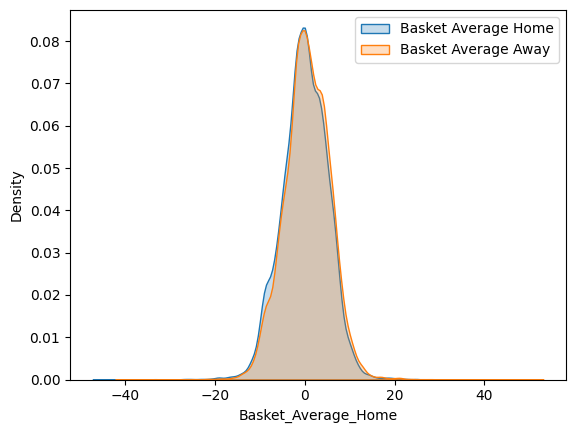

In [15]:
columnas = ['Basket Average Home','Basket Average Away']
for i, col in enumerate(basket_averages.columns):
    sns.kdeplot(basket_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

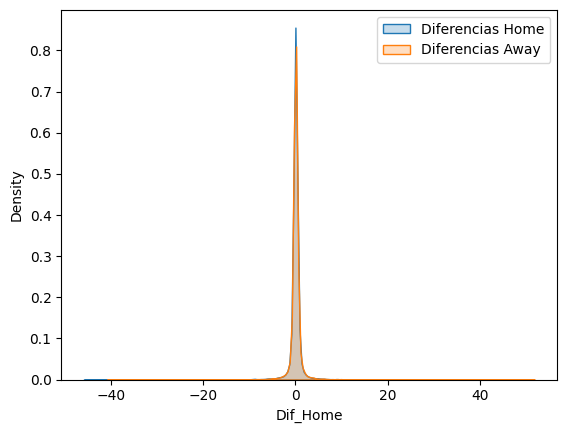

In [16]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

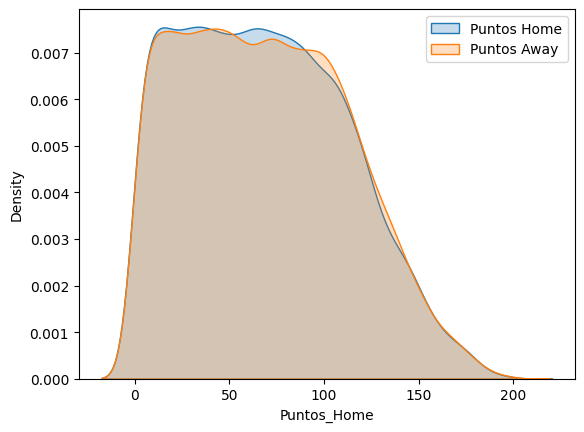

In [17]:
columnas = ['Puntos Home','Puntos Away']
for i, col in enumerate(puntos.columns):
    sns.kdeplot(puntos[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

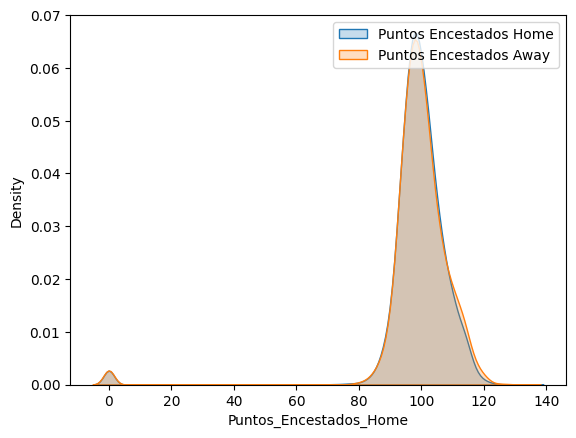

In [18]:
columnas = ['Puntos Encestados Home','Puntos Encestados Away']
for i, col in enumerate(puntos_encestados.columns):
    sns.kdeplot(puntos_encestados[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

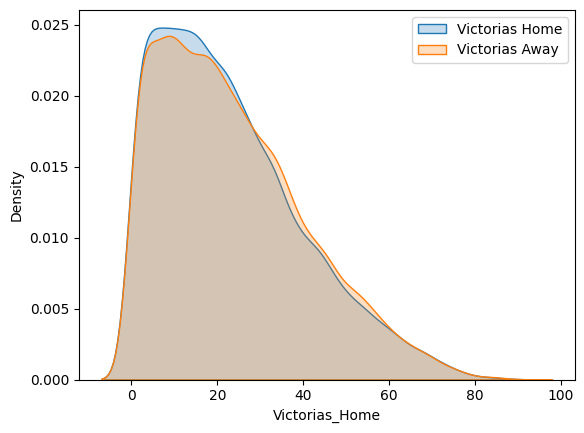

In [19]:
columnas = ['Victorias Home','Victorias Away']
for i, col in enumerate(victorias.columns):
    sns.kdeplot(victorias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

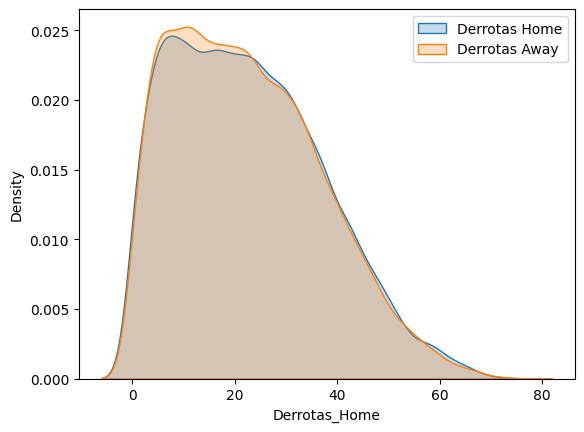

In [18]:
columnas = ['Derrotas Home','Derrotas Away']
for i, col in enumerate(derrotas.columns):
    sns.kdeplot(derrotas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

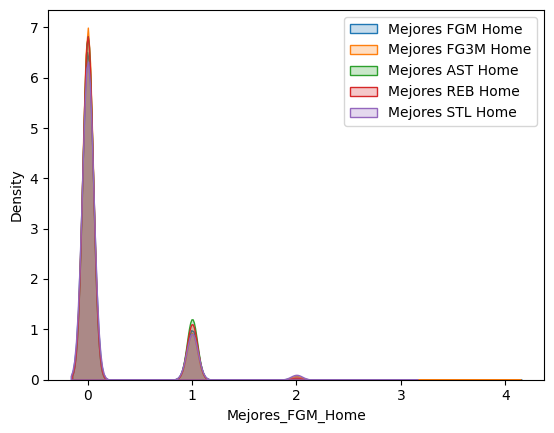

In [22]:
columnas = ['Mejores FGM Home','Mejores FG3M Home','Mejores AST Home','Mejores REB Home','Mejores STL Home']
for i, col in enumerate(mejores_jugadores_home.columns):
    sns.kdeplot(mejores_jugadores_home[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [24]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Basket_Average_Home,Basket_Average_Away,Dif_Home,Dif_Away,Puntos_Home,Puntos_Away,Puntos_Encestados_Home,Puntos_Encestados_Away,Victorias_Home,Derrotas_Home,...,Mejores_FG3M_Home,Mejores_AST_Home,Mejores_REB_Home,Mejores_STL_Home,Mejores_FGM_Away,Mejores_FG3M_Away,Mejores_AST_Away,Mejores_REB_Away,Mejores_STL_Away,SEASON
0,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.755814,0.43956,0.755814,0.43956,0.009852,0.0,0.761194,0.0,0.010989,0.000000,...,0.00,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.372093,0.43956,0.372093,0.43956,0.004926,0.0,0.619403,0.0,0.000000,0.013514,...,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


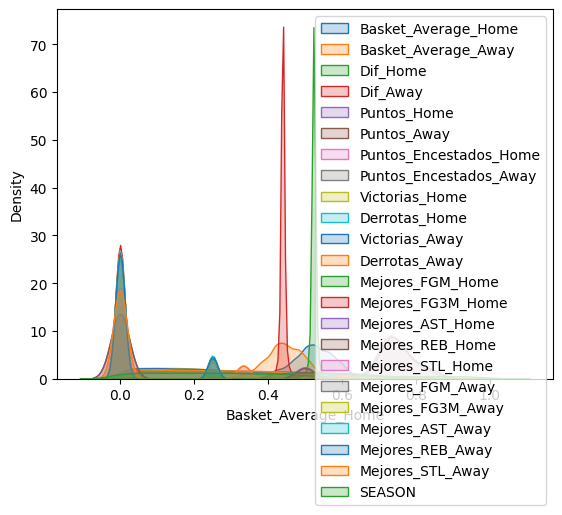

In [25]:
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [26]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(20921, 60)

In [27]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.concatenate((features_normalized_dataframe[columnas_features].values, equipos_encoded), axis=1)

In [28]:
predictores.shape

(20921, 83)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [29]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.2, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (16736, 83) (16736,)
Test set: (4185, 83) (4185,)


### Definición y construcción del modelo

In [34]:
def get_modelo_regresion():
    model = LogisticRegression(max_iter=3000, solver='sag')
    return model

def get_modelo_random_forest():
    model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=4, criterion='log_loss')
    return model

def get_modelo_svc():
    model = SVC(kernel='linear', C=0.5, gamma='scale', probability=True)
    return model

def get_modelo_gbm(): ##mejores resultados pero tarda en entrenar
    model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)  
    return model

def get_modelo_decision_tree():
    model = DecisionTreeClassifier(criterion="log_loss",max_depth=13, random_state=42) 
    return model

def get_modelo_knn(): ##mejor recall en empates
    model = KNeighborsClassifier(n_neighbors=47, metric="minkowski", weights='uniform')
    return model

def get_modelo_naive_bayes():
    #model = GaussianNB()
    model = MultinomialNB()
    return model

model = get_modelo_gbm()

### Entrenamiento del modelo

In [35]:
model.fit(features_train, target_train)
#iteraciones=4
#historial_entrenamiento=model.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

GradientBoostingClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
                           random_state=42)

## -Evaluación del modelo

### Evolución del modelo

In [36]:
target_pred = model.predict(features_test)
accuracy = accuracy_score(target_test, target_pred)
recal = recall_score(target_test, target_pred, average=None)
recal_total = recall_score(target_test, target_pred, average='macro')
precision = precision_score(target_test, target_pred, average=None)
precision_total = precision_score(target_test, target_pred, average='macro')
conf_matrix = confusion_matrix(target_test, target_pred)
print("Accuracy del modelo:", accuracy)
print("Recall del modelo:", recal)
print("Recall del modelo:", recal_total)
print("Precision del modelo:", precision)
print("Precision del modelo:", precision_total)
print("Matriz de Confusión:")
print(conf_matrix)

Accuracy del modelo: 0.709199522102748
Recall del modelo: [0.63455954 0.78197263]
Recall del modelo: 0.708266081966187
Precision del modelo: [0.7394247  0.68698176]
Precision del modelo: 0.7132032308844947
Matriz de Confusión:
[[1311  755]
 [ 462 1657]]


ValueError: The number of FixedLocator locations (85), usually from a call to set_ticks, does not match the number of labels (7).

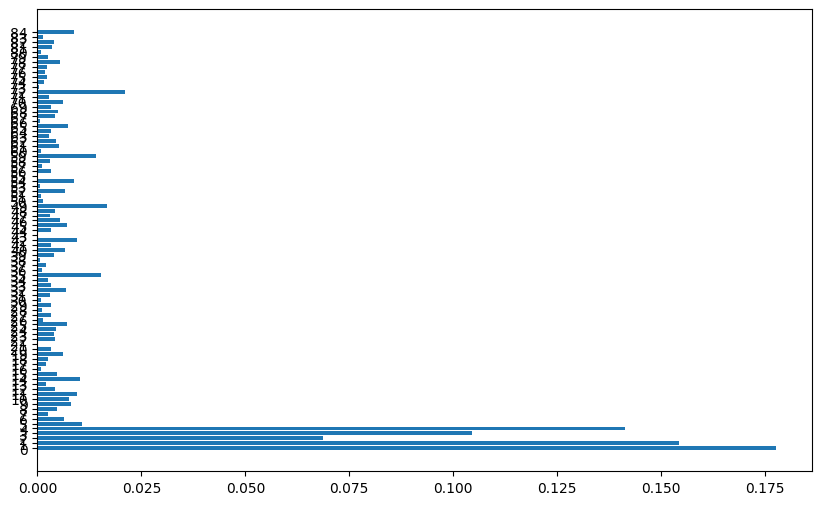

In [273]:
importances = model.feature_importances_

# Obtener nombres de las características
nombres_caracteristicas = ['GAH','GAA','RH','GH','GA','HT','AT']

# Crear un gráfico de barras para visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), nombres_caracteristicas)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las características en Random Forest')
plt.show()

## - Predicción real de un partido

In [142]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Real Madrid'
AT='Osasuna'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [143]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 80)

In [144]:
datos_partido = np.array([
    gol_average_home, gol_average_away,
    dif_home, dif_away,
    rojas_home, rojas_away
]).reshape(1, -1)
datos_partido = scale.transform(datos_partido)
datos_partido.shape

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(1, 6)

In [145]:
predictores = np.concatenate((datos_partido, equipos_encoded), axis=1)
predictores.shape

(1, 86)

### Predicción del valor objetivo

In [146]:
pred1 = model.predict_proba(predictores)
pred1

array([[0.12339029, 0.19494218, 0.68166753]])

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [147]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [148]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [149]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

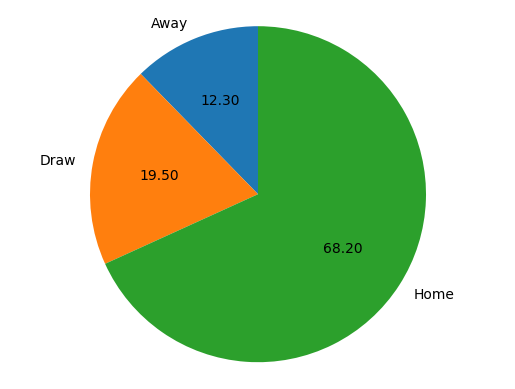

In [150]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()